# Phishing-URL Detection
In this notebook we:
1. Load our URL‐feature CSV
2. Preprocess (select features, encode labels)
3. Split into train/test sets
4. Train a Logistic Regression classifier
5. Evaluate with accuracy, confusion matrix, ROC‐AUC, cross-validation
6. Inspect feature coefficients


## Load Libraries


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report, roc_curve

## Preprocess Data

In [22]:
# Load the dataset
file_name = 'features_extracted.csv'
df = pd.read_csv(file_name)
df.head() # Display the first 5 rows of the dataset

,URL,Status,Label,Domain,Have_IP,Have_At,URL_Length_Over_54,URL_Depth,Redirect_//_Position,HTTP_In_Domain,HTTPS_In_Domain,Prefix_Suffix_Dash,DNS_Record,Domain_Age_Phishing,Subdomains_Phishing
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,Success,bad,nobell.it,0,0,1,8,0,0,0,0,1,0,0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,Success,bad,www.dghjdgf.com,0,0,1,4,0,0,0,0,1,0,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,Success,bad,serviciosbys.com,0,0,1,11,0,0,0,0,1,0,0
3,mail.printakid.com/www.online.americanexpress....,Success,bad,mail.printakid.com,0,0,1,2,0,0,0,0,1,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,Success,bad,thewhiskeydregs.com,0,0,1,7,1,0,0,0,1,0,0


In [23]:
# Select features and target variable
features = [
        'Have_IP','Have_At','URL_Length_Over_54','URL_Depth',
        'Redirect_//_Position','HTTP_In_Domain','HTTPS_In_Domain',
        'Prefix_Suffix_Dash','DNS_Record','Domain_Age_Phishing','Subdomains_Phishing'
    ]

target = 'Label'
x = df[features]
y = df[target].map({'bad': 0, 'good': 1}) # Encode labels as 0 and 1

## Train/Test Split

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=77)

## 1-Logistic Regression Classifier
### Training:

In [25]:
# Create a Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=77)
# Train the model on the training data
model.fit(x_train, y_train)
print("Model trained successfully.")

Model trained successfully.


### Evaluate the Model

In [26]:
# Make predictions on the test set
y_pred = model.predict(x_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred)
# classification report
class_report = classification_report(y_test, y_pred, target_names=['bad', 'good'])

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC-AUC: {roc_auc:.4f}")
print("Classification Report:")
print(class_report)

Accuracy: 0.8327
Confusion Matrix:
[[12797 17419]
 [  792 77853]]
ROC-AUC: 0.7067
Classification Report:
              precision    recall  f1-score   support

         bad       0.94      0.42      0.58     30216
        good       0.82      0.99      0.90     78645

    accuracy                           0.83    108861
   macro avg       0.88      0.71      0.74    108861
weighted avg       0.85      0.83      0.81    108861



### Plot ROC Curve

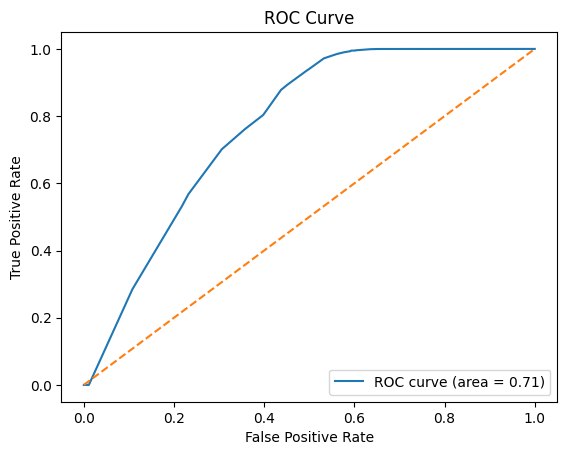

In [27]:
y_proba = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Cross-Validation

In [28]:
cv_scores = cross_val_score(model, x, y, cv=5, scoring='roc_auc')
print(f"Cross-Validation ROC-AUC scores: {cv_scores}")
print(f"Mean ROC-AUC: {np.mean(cv_scores):.4f}")

Cross-Validation ROC-AUC scores: [0.66177119 0.71427516 0.65591077 0.77395433 1.        ]
Mean ROC-AUC: 0.7612


## Feature Importance

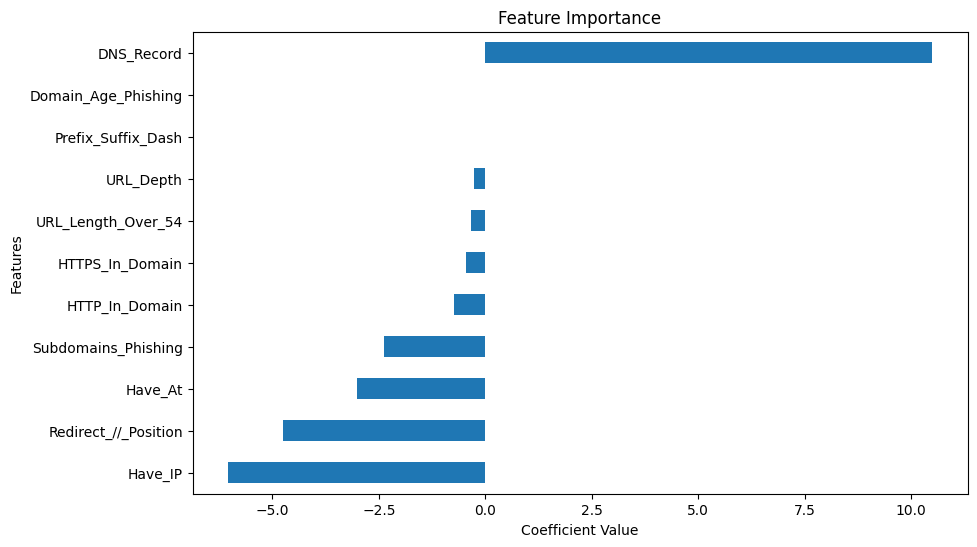

In [29]:
# Get feature coefficients
coefficients = pd.Series(model.coef_[0], index=features).sort_values()
# Plot feature importance
plt.figure(figsize=(10, 6))
coefficients.plot(kind='barh')
plt.title('Feature Importance')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

## 2- Light GBM

## 3- SVM

### Training:


In [30]:
# import SVC model
from sklearn.calibration import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC  # Support Vector Classifier
# Wrap LinearSVC
base_model = LinearSVC()
model = CalibratedClassifierCV(base_model)  # Default is sigmoid calibration
# Train the model on the training data
model.fit(x_train, y_train)
print("SVC Model trained successfully.")

SVC Model trained successfully.


##Evaluate the model


In [31]:
# Make predictions on the test set
y_pred = model.predict(x_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred)
# classification report
class_report = classification_report(y_test, y_pred, target_names=['bad', 'good'])

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC-AUC: {roc_auc:.4f}")
print("Classification Report:")
print(class_report)

Accuracy: 0.8328
Confusion Matrix:
[[12805 17411]
 [  795 77850]]
ROC-AUC: 0.7068
Classification Report:
              precision    recall  f1-score   support

         bad       0.94      0.42      0.58     30216
        good       0.82      0.99      0.90     78645

    accuracy                           0.83    108861
   macro avg       0.88      0.71      0.74    108861
weighted avg       0.85      0.83      0.81    108861



##Plot ROC curve


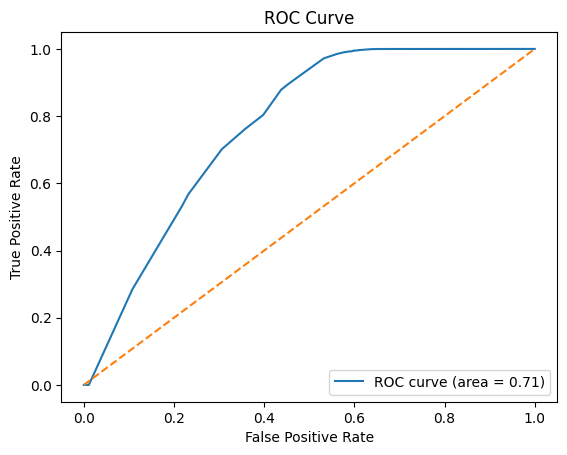

In [32]:
##Plot ROC curve
y_proba = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

###Cross-Validation

In [33]:
cv_scores = cross_val_score(model, x, y, cv=5, scoring='roc_auc')
print(f"Cross-Validation ROC-AUC scores: {cv_scores}")
print(f"Mean ROC-AUC: {np.mean(cv_scores):.4f}")

Cross-Validation ROC-AUC scores: [0.66126393 0.7095445  0.6623428  0.7737775  0.99979174]
Mean ROC-AUC: 0.7613


## 4- Decision Tree

## 5- Random Forest
### Training

In [ ]:
# Create a Random Forest model
rf_model = RandomForestClassifier(n_estimators=1000, random_state=77)
# Train the model
rf_model.fit(x_train, y_train)
print("Model trained successfully.")

Model trained successfully.


### Evaluate the model

In [ ]:
# Make predictions
y_pred_rf = rf_model.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_rf)
# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)
# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_rf)
# classification report
class_report = classification_report(y_test, y_pred_rf, target_names=['bad', 'good'])

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC-AUC: {roc_auc:.4f}")
print("Classification Report:")
print(class_report)

Accuracy: 0.8380
Confusion Matrix:
[[13537 16679]
 [  959 77686]]
ROC-AUC: 0.7179
Classification Report:
              precision    recall  f1-score   support

         bad       0.93      0.45      0.61     30216
        good       0.82      0.99      0.90     78645

    accuracy                           0.84    108861
   macro avg       0.88      0.72      0.75    108861
weighted avg       0.85      0.84      0.82    108861



### Plot ROC Curve

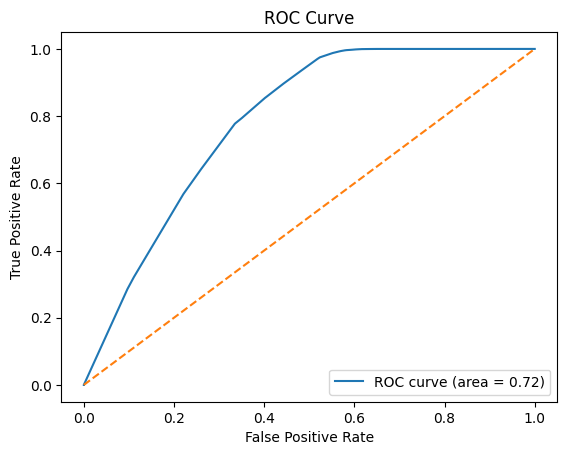

In [ ]:
y_proba_rf = rf_model.predict_proba(x_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Cross-Validation

In [ ]:
cv_scores_rf = cross_val_score(rf_model, x, y, cv=5, scoring='roc_auc')
print(f"Cross-Validation ROC-AUC scores: {cv_scores_rf}")
print(f"Mean ROC-AUC: {np.mean(cv_scores_rf):.4f}")

Cross-Validation ROC-AUC scores: [0.6792985  0.72317143 0.69627575 0.78812409 0.99998807]
Mean ROC-AUC: 0.7774


### Feature Importance

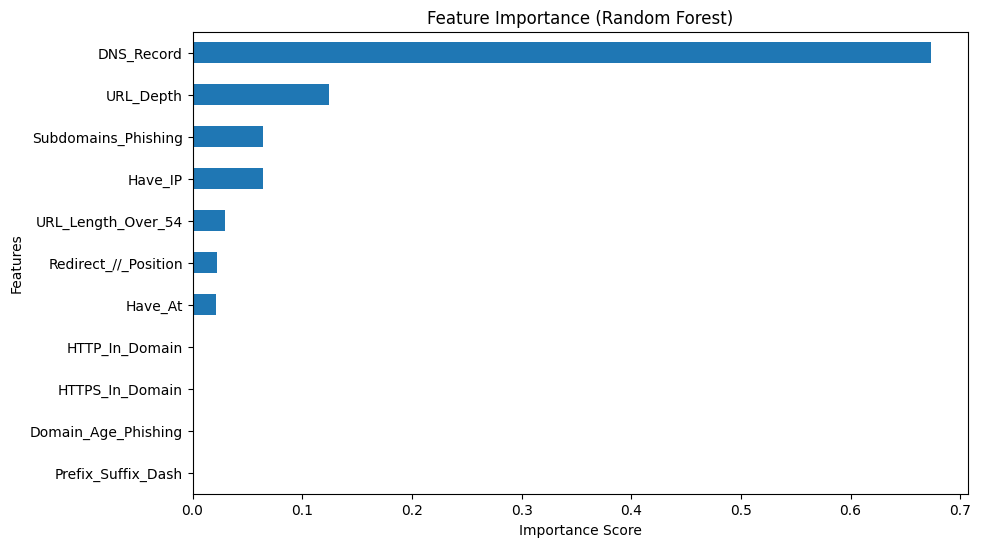

In [ ]:
# Get feature importances from the model
importances = rf_model.feature_importances_

# Create a Pandas Series with feature names as index
importance_series = pd.Series(importances, index=features).sort_values()

# Plot feature importance
plt.figure(figsize=(10, 6))
importance_series.plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()
